# UE05 - Schätzer für Momente und Konfidenzintervalle

Mit dem bisher erlernten Toolkit wollen wir nun versuchen, eine eigene Simulation zur Schätzung des zu erwartenden Gewinns eines Blumengeschäfts zu schreiben. Jener Teil dieser Übung, der sich auf die Konfidenzintervalle bezieht, baut maßgeblich auf eure Erkenntnisse aus UE04 auf, fokussiert sich dabei aber auf das Erstellen von Konfidenzintervallen für Daten, deren Varianz unbekannt ist und diese somit aus den Beobachtungen (=Ergebnisse der Simulation) geschätzt werden muss.

Ein wesentlicher Unterschied zwischen der Erstellung von Konfidenzintervallen für Momente von Daten mit bekannter und unbekannter Varianz ist die Berechnung des Parameters $k$.
Vgl. hierzu das Skript zu Daten und Statistik von Prof. Wegenkittl Abschnitt 4.2 (S. 26ff).

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

## UE05.a)
Simulation "Blumenbeispiel":
<ul>
    <li>Ein Blumenhändler kauft leicht verderbliche Blumen zu einem Stückpreis von 3 Euro bei einem Großhändler ein, welcher allerdings nur in Bündeln zu 5 Stück liefert.</li>
    <li>Aufgrund aktueller Lieferengpässe von Blumen am Markt muss der Blumenhändler seine gewünschte Stückzahl eingekaufter Blumen für ein Jahr im Voraus festlegen.</li>
    <li>Der Verkaufspreis der Blumen für den Blumenhändler beläuft sich auf 7 Euro/Stk.</li>
    <li>Nimm an, dass jede Blume, die nicht am ersten Tag verkauft werden konnte, wertlos ist und weggeworfen wird.</li>
    <li>Die Anzahl $X$ der Blumen, die an einem Tag von Kund:innen des Blumengeschäfts nachgefragt werden, ist eine Zufallsvariable mit folgender Verteilung:</li>
</ul>

|$k$|$0$|$1$|$2$|$3$|$4$|$5$|$6$|$7$|$8$|$9$|$10$|$11$|$12$|$>12$|
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
|$P (X = k)$|$0.01$ |$0.02$ |$0.03$ |$0.04$ |$0.05$ |$0.1$ |$0.2$ |$0.2$ |$0.1$ |$0.09$ |$0.08$ |$0.07$ |$0.01$ |$0$ |

<ol>
    <li>Erstelle eine Simulation, die ein Jahr (=365 Tage) des Blumengeschäftes darstellen kann.<br>
        Zu simulieren ist also (pro Tag):
        <ul>
            <li>Die Anzahl nachgefragter Blumen gegeben $P (X = k)$.
            </li>
            <li>Die Anzahl verkaufter Blumen (Was passiert, wenn die Anzahl nachgefragter Blumen größer ist als die Anzahl eingekaufter Blumen?).
            </li>
            <li>Die daraus resultierende Bilanz (Ausgaben, Einnahmen, Profit bzw. Verlust) des Geschäftes
            </li>
        </ul>
    </li>
    <li>Gib die Ergebnisse des Durchlaufs eines Jahres der Simulation übersichtlich im Notebook aus.</li>
    <li>Wieviele Blumen muss der Blumenhändler täglich beim Großhändler einkaufen, um den zu erwartenden Gewinn zu maximieren? Nimm dabei an, dass aufgrund der Marktsituation die Anzahl eingekaufter Blumen pro Tag für ein jahr im Voraus festgelegt werden muss.
    </li>
    <li>Ab welcher Anzahl eingekaufter Blumen macht der Blumenhändler einen Verlust?
    </li>
</ol>

ERGEBNISSE DER JAHRESSIMULATION:


,Einkaufsmenge/Tag,Gesamte Nachfrage,Verkaufte Blumen,Ausgaben (€),Einnahmen (€),Jahresgewinn (€)
0,0,2454,0,0,0,0
1,5,2454,1690,5475,11830,6355
2,10,2454,2420,10950,16940,5990
3,15,2454,2454,16425,17178,753
4,20,2454,2454,21900,17178,-4722
5,25,2454,2454,27375,17178,-10197


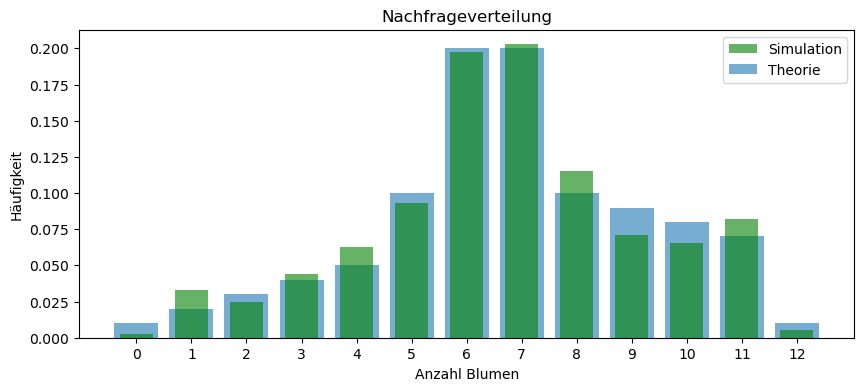

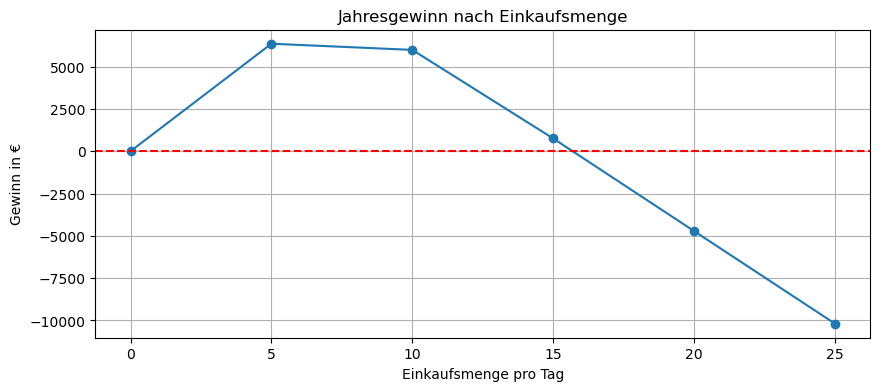

<Figure size 640x480 with 0 Axes>

In [12]:
# Todo: UE05.a)
# Stk_Preis=3€, Stk_Anzahl=5, Ein Jahr im Voraus, VK_preis=7€ pro stk, Nach einem Tag =>Blume wertlos
# X=Anzahl der Blumen, die an einem Tag nachgefragt werden
# Folgender verteilungsfunktion für X: P(X=0)=0.01, P(X=1)=0.02, P(X=2)=0.03, P(X=3)=0.04, P(X=4)=0.05, P(X=5)=0.1, P(X=6)=0.2, P(X=7)=0.2, P(X=8)=0.1, P(X=9)=0.09, P(X=10)=0.08, P(X=11)=0.07, P(X=12)=0.01, P(X>12)=0

#Simulation der Nachfrage, eines 365 Tage, Anzahl Blumen nachgefragt, Anazhl VK_stk, Bilanz (Ausgaben, Einnahmen, Profit bzw. Verlust)
# Simulation der Nachfrage

# Für reproduzierbare Zufallszahlen
np.random.seed(0)

# 0. PARAMETER DEFINIEREN
EINKAUFSPREIS = 3  # € pro Stück
VERKAUFSPREIS = 7   # € pro Stück
TAGE_JAHR = 365

# Wahrscheinlichkeitsverteilung
k_values = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
probs = np.array([0.01, 0.02, 0.03, 0.04, 0.05, 0.10, 0.20, 0.20, 0.10, 0.09, 0.08, 0.07, 0.01])

# Normalisierung sicherstellen (Summe = 1)
probs = probs / probs.sum()

# 1. & 2. SIMULATION FÜR EIN JAHR (365 TAGE)
# Simuliere die Nachfrage für jeden der 365 Tage basierend auf der Verteilung
simulierte_nachfrage = np.random.choice(k_values, size=TAGE_JAHR, p=probs)

# Da der Händler nur in 5er-Bündeln kaufen kann, testen wir sinnvolle Mengen
buendel_optionen = [0, 5, 10, 15, 20, 25]
simulations_ergebnisse = []

for menge in buendel_optionen:
    ausgaben_jahr = menge * EINKAUFSPREIS * TAGE_JAHR
    einnahmen_jahr = 0
    verkauft_jahr = 0
    
    # Schleife über alle 365 Tage
    for tag in range(TAGE_JAHR):
        nachfrage_tag = simulierte_nachfrage[tag]
        # Man kann nicht mehr verkaufen als nachgefragt wird ODER man eingekauft hat
        verkauft_tag = min(nachfrage_tag, menge)
        
        einnahmen_jahr += verkauft_tag * VERKAUFSPREIS
        verkauft_jahr += verkauft_tag
        
    gewinn_jahr = einnahmen_jahr - ausgaben_jahr
    
    simulations_ergebnisse.append({
        "Einkaufsmenge/Tag": menge,
        "Gesamte Nachfrage": simulierte_nachfrage.sum(),
        "Verkaufte Blumen": verkauft_jahr,
        "Ausgaben (€)": ausgaben_jahr,
        "Einnahmen (€)": einnahmen_jahr,
        "Jahresgewinn (€)": gewinn_jahr
    })

# Ergebnisse als übersichtliche Tabelle ausgeben
df_ergebnisse = pd.DataFrame(simulations_ergebnisse)
print("ERGEBNISSE DER JAHRESSIMULATION:")
display(df_ergebnisse)


# Visualisierung
# Plot 1: Nachfrageverteilung
plt.figure(figsize=(10, 4))
plt.bar(k_values, probs, alpha=0.6, label='Theorie')
# hist verwendet, um die simulierten Werte direkt als relative Häufigkeit zu zeigen
plt.hist(simulierte_nachfrage, bins=np.arange(-0.5, 13.5, 1), density=True, alpha=0.6, label='Simulation', rwidth=0.6, color='green')
plt.title('Nachfrageverteilung')
plt.xlabel('Anzahl Blumen')
plt.ylabel('Häufigkeit')
plt.xticks(k_values)
plt.legend()
plt.show()

# Plot 2: Gewinnverlauf
plt.figure(figsize=(10, 4))
plt.plot(df_ergebnisse["Einkaufsmenge/Tag"], df_ergebnisse["Jahresgewinn (€)"], marker='o')
plt.axhline(0, color='red', linestyle='--') # Nulllinie für Verlust/Gewinn
plt.title('Jahresgewinn nach Einkaufsmenge')
plt.xlabel('Einkaufsmenge pro Tag')
plt.ylabel('Gewinn in €')
plt.grid(True)
plt.show()

plt.tight_layout()
plt.show()

## UE05.b)
Konfidenzintervalle zum "Blumenbeispiel":
<ul>
    <li>Berechne das KI für den Erwartungswert der Anzahl täglich nachgefragter Blumen aus UE05.a).</li>
</ul>

<ol>
    <li>Erstelle eine Grafik, die den Verlauf des Erwartungswerts für die Anzahl täglich nachgefragter Blumen, sowie die obere und untere Grenze des KIs $99\%$ Sicherheit über der Anzahl simulierter Tage darstellt.
    </li>
    <li>Wieviele Jahre müssen simuliert werden, um den Erwartungswert täglich nachgefragter Blumen mit $99\%$ Sicherheit auf $1\%$ genau zu schätzen?<br>
        <strong>Achtung:</strong> Aufgrund der Anforderungen an die Sicherheit und Genauigkeit dieser Schätzung ist es eventuell notwendig, eine große Anzahl Tage zu simulieren.
    </li>
    <li>Zeichne in die in UE05.b) 1. erstelle Grafik die Anzahl der Jahre ein, welche in UE05.b) 2. errechnet wurde.
    </li>
</ol>

Theoretischer Erwartungswert (mu): 6.8000
Erlaubte Abweichung (1% von mu):  +/- 0.0680
Notwendige Simulationstage:       8839 Tage
Notwendige Simulationsjahre:      24.22 Jahre



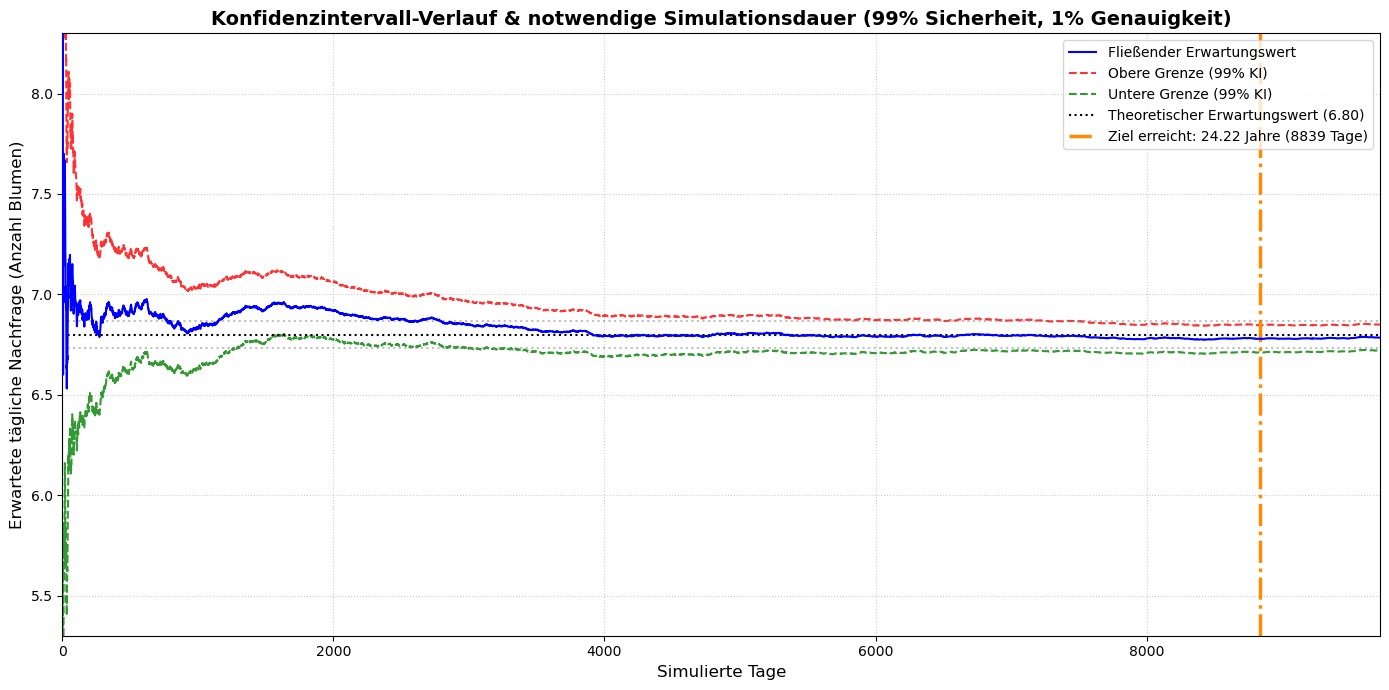

In [15]:
# Theoretischer Erwartungswert (True Mean) und Standardabweichung der Verteilung
theoretischer_erwartungswert = np.sum(k_values * probs)
theoretische_varianz = np.sum((k_values - theoretischer_erwartungswert) ** 2 * probs)
theoretische_std = np.sqrt(theoretische_varianz)

# 2. BERECHNUNG: WIE VIELE JAHRE WERDEN BENÖTIGT? (Teil 2 vorab für Grafik)
# Sicherheit 99% -> Z-Wert für z_(1 - alpha/2) = z_0.995
sicherheit = 0.99
z_wert = stats.norm.ppf(1 - (1 - sicherheit) / 2)

# Genauigkeit: 1% des theoretischen Erwartungswerts
genauigkeit_prozent = 0.01
erlaubte_abweichung = genauigkeit_prozent * theoretischer_erwartungswert

# Formel für den Stichprobenumfang: n = (z * sigma / E)^2
notwendige_tage = (z_wert * theoretische_std / erlaubte_abweichung) ** 2
notwendige_jahre = notwendige_tage / TAGE_JAHR

print(f"Theoretischer Erwartungswert (mu): {theoretischer_erwartungswert:.4f}")
print(f"Erlaubte Abweichung (1% von mu):  +/- {erlaubte_abweichung:.4f}")
print(f"Notwendige Simulationstage:       {notwendige_tage:.0f} Tage")
print(f"Notwendige Simulationsjahre:      {notwendige_jahre:.2f} Jahre\n")


# 1. SIMULATION FÜR DEN VERLAUF (Wir simulieren etwas mehr als die benötigten Tage)
tage_simulation = int(max(TAGE_JAHR * 5, notwendige_tage * 1.1))
simulierte_nachfrage = np.random.choice(k_values, size=tage_simulation, p=probs)

# Arrays für die fortlaufende Berechnung (Tag 1 bis Ende)
tage_achse = np.arange(1, tage_simulation + 1)
fliessender_mittelwert = np.cumsum(simulierte_nachfrage) / tage_achse

# Fortlaufende empirische Standardabweichung berechnen
fehlerspanne_verlauf = z_wert * (theoretische_std / np.sqrt(tage_achse))
obere_grenze = fliessender_mittelwert + fehlerspanne_verlauf
untere_grenze = fliessender_mittelwert - fehlerspanne_verlauf


# Visualisierung des Verlaufs mit den KI-Grenzen
plt.figure(figsize=(14, 7))

# Verlauf des geschätzten Erwartungswerts
plt.plot(
    tage_achse,
    fliessender_mittelwert,
    color="blue",
    label=r"Fließender Erwartungswert",
    zorder=3,
)

# KI Grenzen zeichnen
plt.plot(
    tage_achse,
    obere_grenze,
    color="red",
    linestyle="--",
    alpha=0.8,
    label="Obere Grenze (99% KI)",
)
plt.plot(
    tage_achse,
    untere_grenze,
    color="green",
    linestyle="--",
    alpha=0.8,
    label="Untere Grenze (99% KI)",
)

# Wahre Linie des Erwartungswerts als Orientierung
plt.axhline(
    theoretischer_erwartungswert,
    color="black",
    linestyle=":",
    label=f"Theoretischer Erwartungswert ({theoretischer_erwartungswert:.2f})",
)

# UE05.b) 3. Einzeichnen der berechneten Jahre/Tage als vertikale Linie
plt.axvline(
    x=notwendige_tage,
    color="darkorange",
    linestyle="-.",
    linewidth=2.5,
    label=f"Ziel erreicht: {notwendige_jahre:.2f} Jahre ({notwendige_tage:.0f} Tage)",
)

# Hilfslinien zur Verdeutlichung der 1% Grenzen am Zielpunkt
plt.axhline(
    theoretischer_erwartungswert + erlaubte_abweichung,
    color="gray",
    linestyle=":",
    alpha=0.5,
)
plt.axhline(
    theoretischer_erwartungswert - erlaubte_abweichung,
    color="gray",
    linestyle=":",
    alpha=0.5,
)

# Achsen-Beschränkung für bessere Übersicht (fokussiert auf den Zielbereich)
plt.xlim(0, notwendige_tage * 1.1)
# Y-Achse leicht um den Erwartungswert herum einschränken, damit man das "Eintrichtern" sieht
plt.ylim(theoretischer_erwartungswert - 1.5, theoretischer_erwartungswert + 1.5)

# Beschriftungen und Layout
plt.title(
    "Konfidenzintervall-Verlauf & notwendige Simulationsdauer (99% Sicherheit, 1% Genauigkeit)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Simulierte Tage", fontsize=12)
plt.ylabel("Erwartete tägliche Nachfrage (Anzahl Blumen)", fontsize=12)
plt.legend(loc="upper right", fontsize=10)
plt.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()